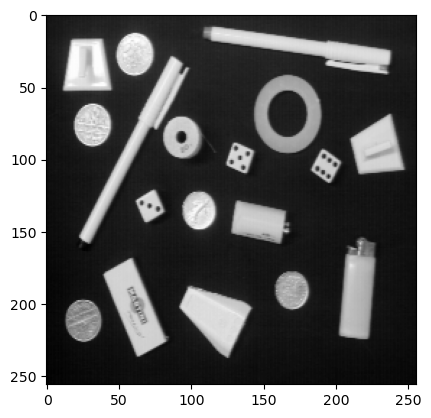

In [51]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("images/OBJECTS.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(image, cmap="gray")
plt.show()

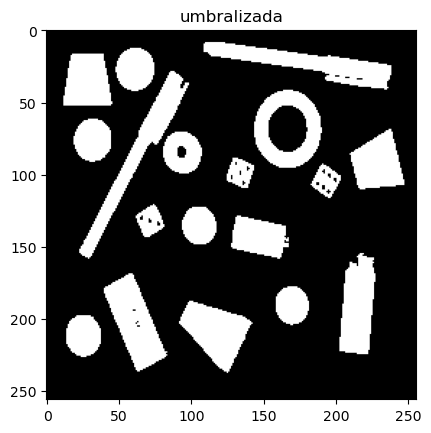

In [52]:
# Umbralice esta imagen para separar los objetos del fondo (umbral=70).

retval, umbralizada = cv2.threshold(image, 70, 255, cv2.THRESH_BINARY)

plt.imshow(umbralizada, cmap="gray")
plt.title("umbralizada")
plt.show()

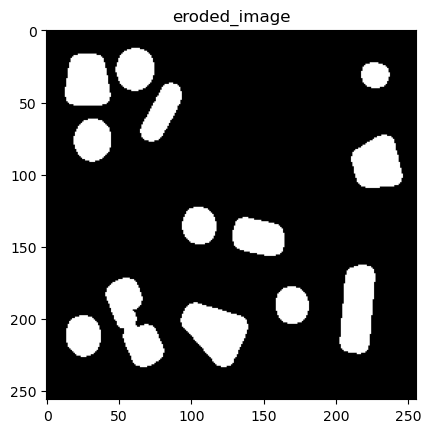

In [53]:
#Realice las operaciones necesarias (incluyendo operaciones morfológicas y de segmentación)
# sobre esta imagen binaria para conservar únicamente los objetos de espesor de por lo menos 15 píxeles.

import numpy as np

fp = np.array([
[0,0,0,0,0,0,1,1,1,0,0,0,0,0,0],
[0,0,0,1,1,1,1,1,1,1,1,1,0,0,0],
[0,0,1,1,1,1,1,1,1,1,1,1,1,0,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[0,0,1,1,1,1,1,1,1,1,1,1,1,0,0],
[0,0,0,1,1,1,1,1,1,1,1,1,0,0,0],
[0,0,0,0,0,0,1,1,1,0,0,0,0,0,0]
])

from skimage.morphology import dilation, erosion, opening, closing


eroded_image = opening(umbralizada, footprint=fp)

plt.imshow(eroded_image, cmap="gray", vmin=0, vmax=255)
plt.title("eroded_image")
plt.show()

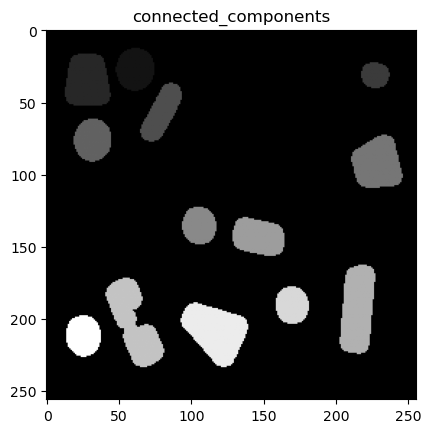

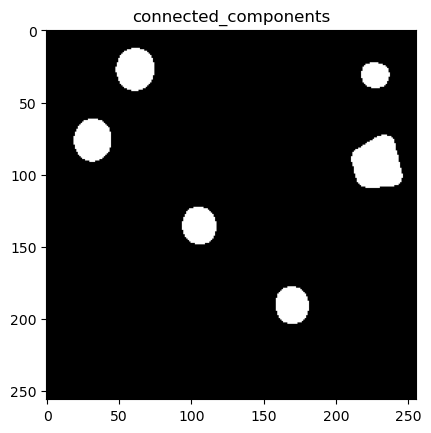

In [54]:
from skimage.measure import label, regionprops

connected_components = label(eroded_image, background=0, connectivity=2)

plt.imshow(connected_components, cmap="gray")
plt.title("connected_components")
plt.show()

regions = regionprops(connected_components)

result = np.zeros_like(umbralizada)

for r in regions:
    if r.eccentricity < 0.5:
        result[connected_components == r.label] = 255

plt.imshow(result, cmap="gray")
plt.title("connected_components")
plt.show()